# Slippery Gridworld
The Gridworld problem is another classic RL problem. It generally involves exploring a grid from a starting cell and finding the exit cell in the least amount of steps possible. Our gridworld has some characteristics, though, that make the problem harder:
- each step leads a reward of $-1$, enhancing the agent to exit it in the lowest amount of steps possile
- some cells are "forbidden": if the agent lands on a forbidden cells it gets a reward of $-100$ and is reset to the starting cell
- regardless of the chosen action, the agent may "slip" with a fixed slip probability ($p=0.1$ in the notebook), that means that the action will be "go down" instead of the intended action. We will build the grid in order to make this effect negative, so that the agent must account for the chance of taking the wrong action by chance


INDICES:
**0: up, 1: down, 2: left, 3: right**


### References
[1] Strens, 2000, A Bayesian Framework for Reinforcement Learning, https://dl.acm.org/doi/10.5555/645529.658114


[2] Ghavamzadeh et al., 2016, Bayesian Reinforcement Learning: A Survey, https://arxiv.org/abs/1609.04436

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from matplotlib.patches import Rectangle, FancyArrow
from matplotlib.patches import Patch
from collections import defaultdict

os.makedirs('Slippery_Gridworld',exist_ok = True)
folder_name = 'Slippery_Gridworld/'
slip = 0.1
n_episodes = 2500

## Gridworld setup and DP solution
Here we setup the gridworld and provide an estimate of the solution with Dynamic Programming

In [2]:
def plot_grid_value(gridworld,color_gradient,start_cells,forbidden_cells,terminal_cells,savepath):
    h,b = np.shape(gridworld)
    plt.figure(figsize=(b, h))
    if color_gradient:
        plt.imshow(gridworld, cmap='viridis', vmin=np.min(gridworld), vmax=np.max(gridworld), aspect='equal')
    else:
        plt.imshow(gridworld, cmap='grey', vmin=-1, vmax=0, aspect='equal')
    
    plt.gca().set_xticks(np.arange(-0.5, b, 1), minor=True)
    plt.gca().set_yticks(np.arange(-0.5, h, 1), minor=True)
    plt.grid(which='minor', color='black', linewidth=1)

    # color starting cells
    for start_cell in start_cells:
        row, col = start_cell
        color = 'green'
        rect = Rectangle((col - 0.5, row - 0.5), 1, 1, 
                     facecolor=color, edgecolor='none', alpha=0.8)
        plt.gca().add_patch(rect)
        
    # color forbidden cells
    for start_cell in forbidden_cells:
        row, col = start_cell
        color = 'red'
        rect = Rectangle((col - 0.5, row - 0.5), 1, 1, 
                     facecolor=color, edgecolor='none', alpha=0.8)
        plt.gca().add_patch(rect)

    # color ending cells
    for start_cell in terminal_cells:
        row, col = start_cell
        color = 'grey'
        rect = Rectangle((col - 0.5, row - 0.5), 1, 1, 
                     facecolor=color, edgecolor='none', alpha=0.8)
        plt.gca().add_patch(rect)

    
    plt.xticks([])
    plt.yticks([])
    # Create custom legend
    legend_elements = [
        Patch(facecolor='green', edgecolor='black', label='starting cell', alpha=0.8),
        Patch(facecolor='red', edgecolor='black', label='forbidden cell', alpha=0.8),
        Patch(facecolor='grey', edgecolor='black', label='terminal cell', alpha=0.8)
    ]
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
    # Add text annotations with gridworld values
    for i in range(gridworld.shape[0]):
        for j in range(gridworld.shape[1]):
            # do not print text if cell is starting or ending or forbidden
                if ((i,j) not in (start_cells+forbidden_cells+terminal_cells)):
                    plt.text(j, i, str(gridworld[i, j]), 
                            ha='center', va='center', fontsize=int(10), color='black')
    plt.savefig(savepath)
    plt.show()

def plot_grid_actions(pi,start_cells,forbidden_cells,terminal_cells,savepath):
    h,b = np.shape(pi)
    plt.figure(figsize=(b, h))
    
    plt.imshow(np.ones_like(pi), cmap='grey', vmin=0, vmax=1, aspect='equal')
    
    plt.gca().set_xticks(np.arange(-0.5, b, 1), minor=True)
    plt.gca().set_yticks(np.arange(-0.5, h, 1), minor=True)
    plt.grid(which='minor', color='black', linewidth=1)

    # color starting cells
    for start_cell in start_cells:
        row, col = start_cell
        color = 'green'
        rect = Rectangle((col - 0.5, row - 0.5), 1, 1, 
                     facecolor=color, edgecolor='none', alpha=0.8)
        plt.gca().add_patch(rect)
        
    # color forbidden cells
    for start_cell in forbidden_cells:
        row, col = start_cell
        color = 'red'
        rect = Rectangle((col - 0.5, row - 0.5), 1, 1, 
                     facecolor=color, edgecolor='none', alpha=0.8)
        plt.gca().add_patch(rect)

    # color ending cells
    for start_cell in terminal_cells:
        row, col = start_cell
        color = 'grey'
        rect = Rectangle((col - 0.5, row - 0.5), 1, 1, 
                     facecolor=color, edgecolor='none', alpha=0.8)
        plt.gca().add_patch(rect)

    for i in range(pi.shape[0]):
        for j in range(pi.shape[1]):
                
            if (i, j) not in (forbidden_cells + terminal_cells):
                #print(f'arrow in {i},{j}, value {action}')
                action = int(pi[i, j])
                    
                dx, dy = 0, 0
                arrow_scale = 0.3
                    
                if action == 0:      # up
                    dy = arrow_scale
                elif action == 1:    # down
                    dy = -arrow_scale
                elif action == 2:    # left
                    dx = -arrow_scale
                elif action == 3:    # right
                    dx = arrow_scale
                    
                plt.arrow(
                        j - dx*0.5,
                        i - dy*0.5,
                        dx,
                        dy,
                        head_width=0.15,
                        head_length=0.15,
                        fc='black',
                        ec='black',
                        linewidth=2,
                        length_includes_head=True,
                        zorder=5
                )
    
    plt.xticks([])
    plt.yticks([])
    # Create custom legend
    legend_elements = [
        Patch(facecolor='green', edgecolor='black', label='starting cell', alpha=0.8),
        Patch(facecolor='red', edgecolor='black', label='forbidden cell', alpha=0.8),
        Patch(facecolor='grey', edgecolor='black', label='terminal cell', alpha=0.8)
    ]
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
    plt.savefig(savepath)
    plt.show()
    

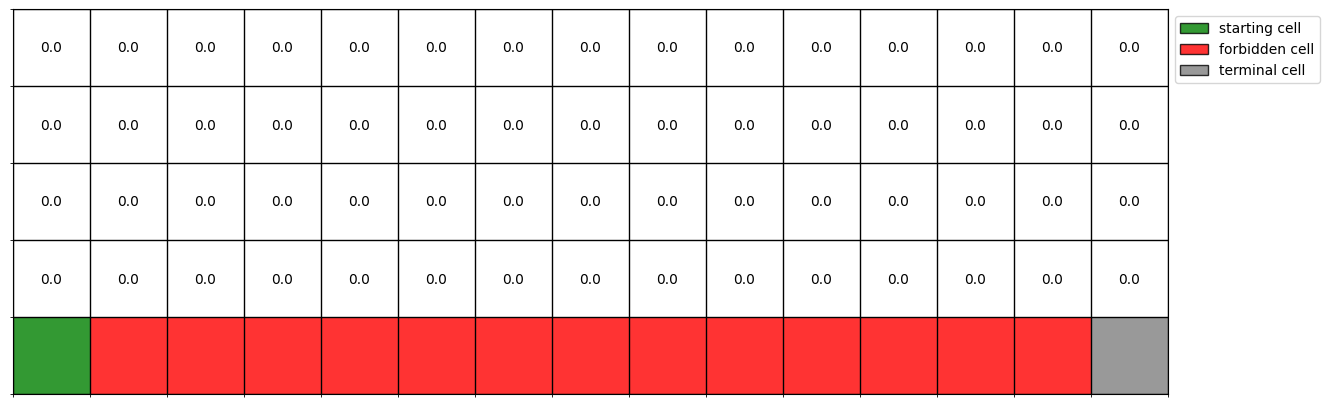

In [3]:
b = 15 # x size of gridworld
h = 5 # y size of gridworld

gridworld = np.zeros((h,b))  # rows, columns
color_gradient = False
start_cells = [(h-1,0)]
forbidden_cells = [(h-1,1),(h-1,2),(h-1,3),(h-1,4),(h-1,5),(h-1,6),(h-1,7),(h-1,8),(h-1,9),(h-1,10),(h-1,11),(h-1,12),(h-1,13)]
terminal_cells = [(h-1,b-1)]

folder_name = folder_name + f'{h}x{b}_{len(forbidden_cells)}_{slip}_{n_episodes}'
os.makedirs(folder_name, exist_ok = True)
savepath = folder_name + '/1_starting_grid.png'
plot_grid_value(gridworld,color_gradient,start_cells,forbidden_cells,terminal_cells,savepath)




We have set up a $15x5$ grid in which the lowest row is made of forbidden cells. This way the "slip chance" leads to a very negative effect. The goal of the agent is to get to the end of the gridworld avoiding slipping (that would increase the amount of steps needed to reach the end and decrease the amount of reward got).

In [4]:
def policy_evaluator(policy,gridworld,starts,ends,forbiddens,max_steps,eval_episodes,slip):
    h,b = np.shape(gridworld)
    rewards = np.zeros(eval_episodes)
    steps = np.zeros(eval_episodes)
    for episode in range(eval_episodes):
        # initialize episode
        step_counter = 0
        total_reward = 0
        state = np.array(list(starts[0]))
        action = policy[state[0],state[1]]

        # loop through episode
        while step_counter < max_steps and (state[0],state[1]) not in ends:
            new_state = state + ACTION_DELTAS[action]
            r = -1
            # boundary check
            #print(new_state)
            if not(0 <= new_state[0] < h and 0 <= new_state[1] < b):
                new_state = state
            # forbidden state check
            if (new_state[0],new_state[1]) in forbiddens:
                r = -100
                new_state = starts[0]
            total_reward += r
            step_counter +=1

            state = new_state
            # choose next action
            action = policy[state[0],state[1]]

            # slip chance
            rand = np.random.uniform(0,1)
            if rand < slip:
                action = 1 # down

        # store data
        rewards[episode] = total_reward
        steps[episode] = step_counter

    return np.mean(rewards),np.std(rewards),np.mean(steps),np.std(steps)
    

In [5]:
# DYNAMIC PROGRAMMING EVALUATOR
def dp_eval(gridworld,starts,forbiddens,ends,gamma):
    # initialize V(s) and pi(s) arbitrarily for all of them
    V = np.zeros_like(gridworld)
    h,b = np.shape(gridworld)
    pi = np.random.randint(4,size = (h,b))     # random actions indexes = 0,1,2,3
    set_of_actions = [(0,1),(0,-1),(-1,0),(1,0)] # up, down, left, right

    # terminal states must have zeros, as well as forbiddens
    for terminal in ends+forbiddens:
        V[terminal[0],terminal[1]]=0

    ####################
    # POLICY ITERATION #
    #################### 
    policy_stable = False
    while policy_stable == False:
        # POLICY EVALUATION LOOP
        theta = 0.1  # accuracy thresh
        delta = 0.5
        while delta > theta:
            delta = 0
            # loop across states
            for x_cell in range(np.shape(gridworld)[0]):
                for y_cell in range(np.shape(gridworld)[1]):
                    
                    # check if analyzed cell is not in prohibited states
                    if (x_cell, y_cell) not in ends+forbiddens:
                        v = V[x_cell,y_cell]
    
                        temp = 0
                        # check if action brings to an illegal cell
                        # if not update value estimate
                        
                        action = set_of_actions[pi[x_cell,y_cell]]
                        new_x = x_cell + action[0] 
                        new_y = y_cell + action[1]
                        if (new_x,new_y) not in forbiddens and new_x >= 0 and new_x < h and new_y >= 0 and new_y < b:
                            temp += -1 + gamma * V[x_cell + action[0],y_cell + action[1]]
                        if (new_x,new_y) in forbiddens:
                            temp += -100 + gamma * V[x_cell + action[0],y_cell + action[1]]
                        V[x_cell,y_cell] = temp
                        delta = max(delta,abs(v-temp))
    
        # POLICY IMPROVEMENT LOOP
        policy_stable = True
        # loop across states
        for x_cell in range(np.shape(gridworld)[0]):
            for y_cell in range(np.shape(gridworld)[1]):
                    
                # check if analyzed cell is not in prohibited states
                if (x_cell, y_cell) not in ends+forbiddens:
                    old_action = pi[x_cell,y_cell]
    
                    # check whether the action brings inside a prohibited state or not
                    temp = []
                    valid_actions = []
                    for action_idx in range(len(set_of_actions)):
                        action = set_of_actions[action_idx]
                        new_x = x_cell + action[0] 
                        new_y = y_cell + action[1]
                        if (new_x,new_y) not in forbiddens and new_x >= 0 and new_x < h and new_y >= 0 and new_y < b:
                            temp.append(-1 + gamma * V[new_x, new_y])
                            valid_actions.append(action_idx)
                    
                    best_action = valid_actions[np.argmax(np.array(temp))]
                    pi[x_cell,y_cell] = best_action
                    if best_action != old_action:
                        policy_stable = False
        #print(V)
    # if policy iteration has finished, return results
    for x_cell in range(np.shape(V)[0]):
        for y_cell in range(np.shape(V)[1]):
            V[x_cell,y_cell] = round(V[x_cell,y_cell],2)
    return V, pi   # V ~ V*, pi ~ pi*
    

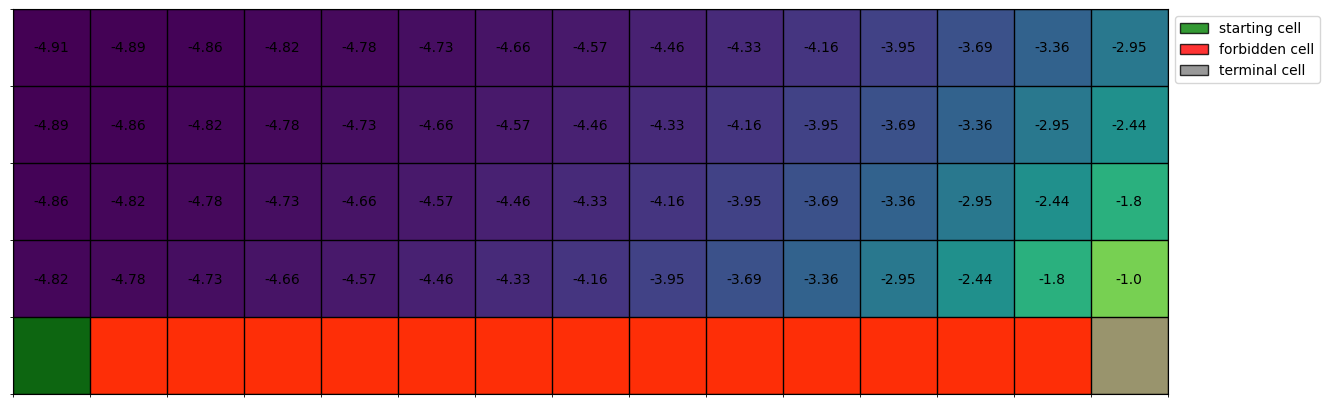

In [6]:
gamma = 0.8
Vstar, pistar = dp_eval(gridworld,start_cells,forbidden_cells,terminal_cells,gamma)
color_gradient = True

savepath = folder_name + '/2_DP_solution.png'
plot_grid_value(Vstar,color_gradient,start_cells,forbidden_cells,terminal_cells,savepath)
    

In [7]:
Vstar

array([[-4.91, -4.89, -4.86, -4.82, -4.78, -4.73, -4.66, -4.57, -4.46,
        -4.33, -4.16, -3.95, -3.69, -3.36, -2.95],
       [-4.89, -4.86, -4.82, -4.78, -4.73, -4.66, -4.57, -4.46, -4.33,
        -4.16, -3.95, -3.69, -3.36, -2.95, -2.44],
       [-4.86, -4.82, -4.78, -4.73, -4.66, -4.57, -4.46, -4.33, -4.16,
        -3.95, -3.69, -3.36, -2.95, -2.44, -1.8 ],
       [-4.82, -4.78, -4.73, -4.66, -4.57, -4.46, -4.33, -4.16, -3.95,
        -3.69, -3.36, -2.95, -2.44, -1.8 , -1.  ],
       [-4.86,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ]])

We note that states close to the forbidden cells **are not penalized by Dynamic Programming**. This is due to the fact that DP **ignores slipping**, since it provides only the best possible estimate from each available state. 

## Monte Carlo Solution
We first try to implement MC as in the chain problem. The algorithm is the following:
1) Random initialization of policy $\pi$ and state-action values $Q(s,a)$ for all $(s,a)$ pairs
2) Initialization of the episode (initial state) and ensurement that all actions have probability > 0 (ensure exploration)
3) Run a complete episode following $\pi$
4) Compute the returns as $G_t = R_t + G_{t-1}$ for $t = T-1,...,0$ (reversing time saves computational resources)
5) (FIRST VISIT), for all $t$, if $(s_t,a_t)$ not in $[(s_{t-1},a_{t-1}),...,(s_0,a_0))$, append $G$ to returns of $(s_t,a_t)$ and update $Q(s_t,a_t) = <returns(s_t,a_t)>$ (mean of recorded returns)
6) Go back to 2.

The gridworld has a state-action space with significantly higher cardinality than the chain problem. This reduces drammaticaly the chance of MC randomly discovering the best solution, or even a suitable good solution

In [8]:
# initial setup
Q = np.zeros((h,b,4))   # state:(row, col), action: up,down,left,right

# setup policy randomly (uniform across all actions)
pi = np.ones((h,b,4))
for i in range(np.shape(pi)[0]):
    for j in range(np.shape(pi)[1]):
        norm_factor = np.sum(pi[i,j,:])
        pi[i,j,:] = pi[i,j,:] / norm_factor



gamma = 0.8
epsilon = 0.05
max_steps = int(max(b,h)**3)*2



In [9]:
# MC loop - GENERATE EPISODE FOLLOWING PI
returns_count = defaultdict(lambda: defaultdict(int))
actions = np.arange(0,4,1)  # UP 0    DOWN 1    LEFT 2    RIGHT 3
ACTION_DELTAS = np.array([
    [1, 0],   # up
    [-1,  0],   # down
    [0, -1],   # left
    [0,  1]    # right
])

rewards = []
path_lengths = []
# initialize state 
for _ in range(n_episodes):
    seen_s = []
    seen_a = []
    seen_r = []
    s = start_cells[0]
    
    for _ in range(max_steps):
        
        a = np.random.choice(actions, p = pi[s[0],s[1],:])
        seen_s.append(s)
        # slip chance
        rand = np.random.uniform(0,1)
        if rand < slip:
            a = 1
        seen_a.append(a)
        r = -1
    
        new_s = s + ACTION_DELTAS[a]
        # boundary check
        if (0 <= new_s[0] < h and 0 <= new_s[1] < b):
            s = new_s
        if tuple(s) in terminal_cells:
            seen_r.append(r)
            break
        if tuple(s) in forbidden_cells:
            # reset and r = -100
            r = -100
            s = start_cells[0]
            
        seen_r.append(r)
        
    # at the end of episode we update
    G = 0
    visited = set()
    for t in reversed(range(len(seen_s)-1)):
        G = gamma * G + seen_r[t]
        s = tuple(seen_s[t])  # <-- convert to tuple
        a = seen_a[t]
    
        if (s,a) in visited:
            continue
        visited.add((s,a))
    
        row, col = s
        count = returns_count[s][a]
    
        Q[row, col, a] += (G - Q[row, col, a]) / (count + 1)
        returns_count[s][a] += 1
    
        best_a = np.argmax(Q[row, col])
        pi[row, col] = epsilon / 4
        pi[row, col, best_a] += 1 - epsilon
    rewards.append(np.sum(np.array(seen_r)))
    
    path_lengths.append(len(seen_r))

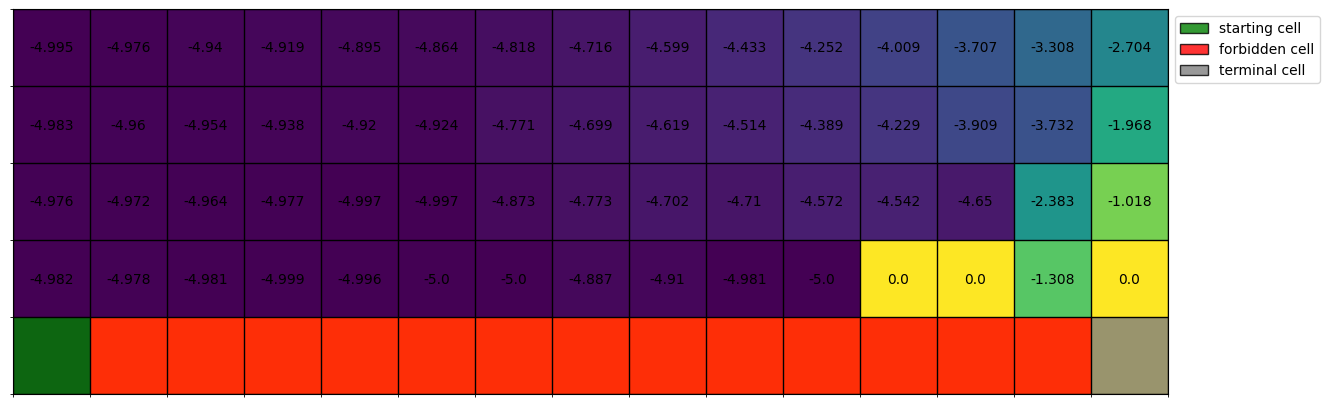

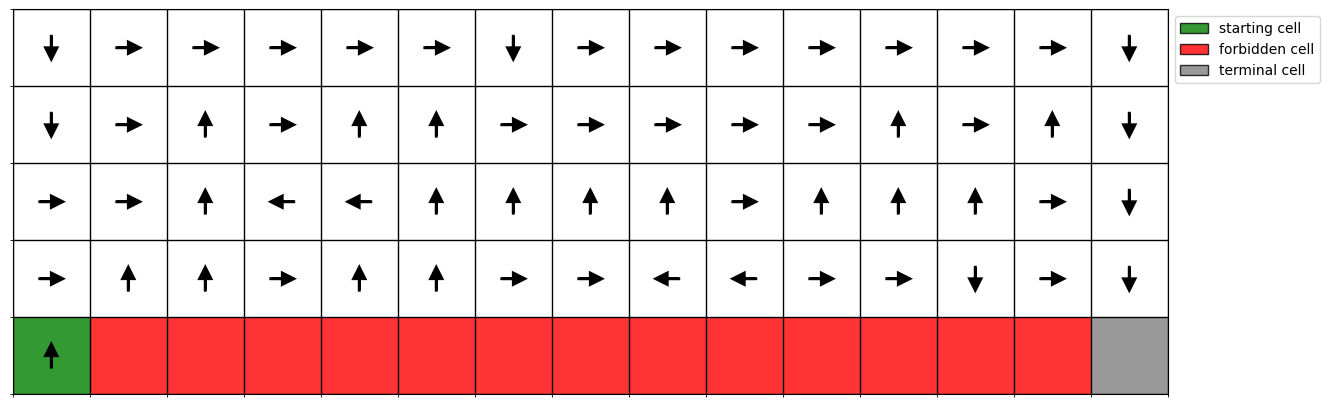

In [10]:
Qstar = np.round(np.max(Q,axis = 2),3)
savepath = folder_name + '/3_MC_value.png'
plot_grid_value(Qstar,color_gradient,start_cells,forbidden_cells,terminal_cells,savepath)

savepath = folder_name + '/3_MC_actions.png'
plot_grid_actions(np.argmax(Q,axis = 2),start_cells,forbidden_cells,terminal_cells,savepath)
    

In [11]:
policy = np.argmax(Q,axis = 2)
eval_episodes = 100
eval_mean_r,eval_std_r,eval_mean_s,eval_std_s = policy_evaluator(policy,gridworld,start_cells,terminal_cells,forbidden_cells,max_steps,eval_episodes,slip)


avg_rewards = []
for i in range(1,len(rewards)):
    avg_rewards.append(np.sum(rewards[:i])/i)

avg_path = []
for i in range(1,len(path_lengths)):
    avg_path.append(np.sum(path_lengths[:i])/i)


MC_dict = {
    'episodes':n_episodes,
     #'avg_rewards':avg_rewards,
     #'rewards':rewards,
    'epsilon':epsilon,
    'gamma':gamma,
    'avg_path_length':avg_path,
    'EVAL_episodes':eval_episodes,
    'EVAL_mean_reward':eval_mean_r,
    'EVAL_std_reward':eval_std_r,
    'EVAL_mean_steps':eval_mean_s,
    'EVAL_std_steps':eval_std_s
}

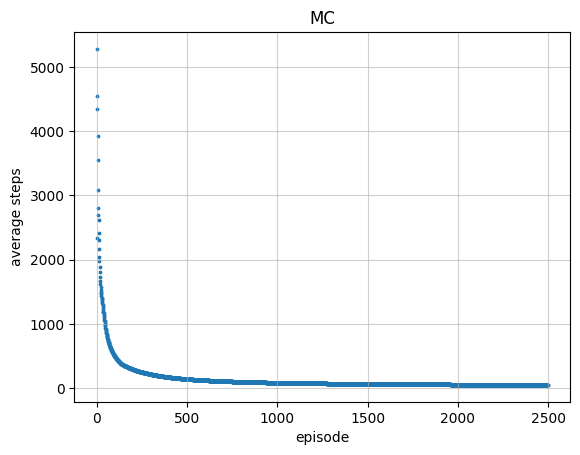

In [12]:
plt.scatter(np.arange(0,len(avg_path),1),avg_path,s =3)
plt.xlabel('episode')
plt.ylabel('average steps')
plt.grid(alpha = 0.6)
plt.title('MC')

savepath = folder_name + '/3_MC_steps.png'
plt.savefig(savepath)
plt.show()

In [13]:
print(MC_dict['EVAL_mean_reward'],MC_dict['EVAL_std_reward'])

-26.09 1.8060730882220686


# SARSA solution
We then try to implement SARSA. The algorithm is the following:
1) Random initialization of policy $\pi$ and state-action values $Q(s,a)$ for all $(s,a)$ pairs
2) Initialization of the episode (initial state) and ensurement that all actions have probability > 0 (ensure exploration)
3) Take action $A$ from $S$ based on $\pi$
4) Observe $R$ and $S'$ (arrival state)
5) Choose $A'$ from $S'$ based on $\pi$ (commitment of the next action is done before the update)
6) Update $Q(S,A)=Q(S,A)+\alpha(R + \gamma Q(S',A') -Q(S,A))$
7) Go back to 3. until the end of episode
8) Loop from 2. until convergence


The gridworld problem does not punish heavily early updates and naive exploration as the chain problem does. SARSA is expected to perform better than MC in this scenario.

In [14]:
# initial setup
Q = np.zeros((h,b,4))   # state:(row, col), action: up,down,left,right

# setup policy randomly (uniform across all actions)
pi = np.ones((h,b,4))
for i in range(np.shape(pi)[0]):
    for j in range(np.shape(pi)[1]):
        norm_factor = np.sum(pi[i,j,:])
        pi[i,j,:] = pi[i,j,:] / norm_factor



alpha = 0.1


In [15]:
# SARSA loop
rewards = []
path_lengths = []
for episode in range(n_episodes):
    # episode initialization
    state = start_cells[0]
    # greedy action choice
    action_idx = np.random.choice(actions,p=pi[state[0],state[1],:])
    # loop until end of episode
    step_counter = 0
    episode_reward = 0
    while step_counter < max_steps and (state[0],state[1]) not in terminal_cells:
        # new state
        new_state = state + ACTION_DELTAS[action_idx]
        r = -1 # basic reward for a step
        # boundary check (if not legal you stay in same state)
        if not(0 <= new_state[0] < h and 0 <= new_state[1] < b):
            new_state = state
        if tuple(new_state) in terminal_cells:
            break
        if tuple(new_state) in forbidden_cells:
            # reset and r = -100
            r = -100
            new_state = start_cells[0]
                
        # epsilon greedy action selection
        new_action_idx = np.random.choice(actions, p = pi[new_state[0],new_state[1],:])
        # slip chance
        rand = np.random.uniform(0,1)
        if rand < slip:
            new_action_idx = 1   # down
        # update state-action value
        Q[state[0],state[1],action_idx] = Q[state[0],state[1],action_idx]+alpha * (r+gamma * Q[new_state[0],new_state[1],new_action_idx]-Q[state[0],state[1],action_idx])
    
        # update policy with epsilon greedy
        best_action = np.argmax(Q[state[0],state[1],:])
        pi[state[0],state[1],:] = epsilon / 4.
        pi[state[0],state[1],best_action] += 1.-epsilon
    
        # update state and action
        state = new_state
        action_idx = new_action_idx
        step_counter += 1
        episode_reward += r
    rewards.append(episode_reward)
    path_lengths.append(step_counter)
    

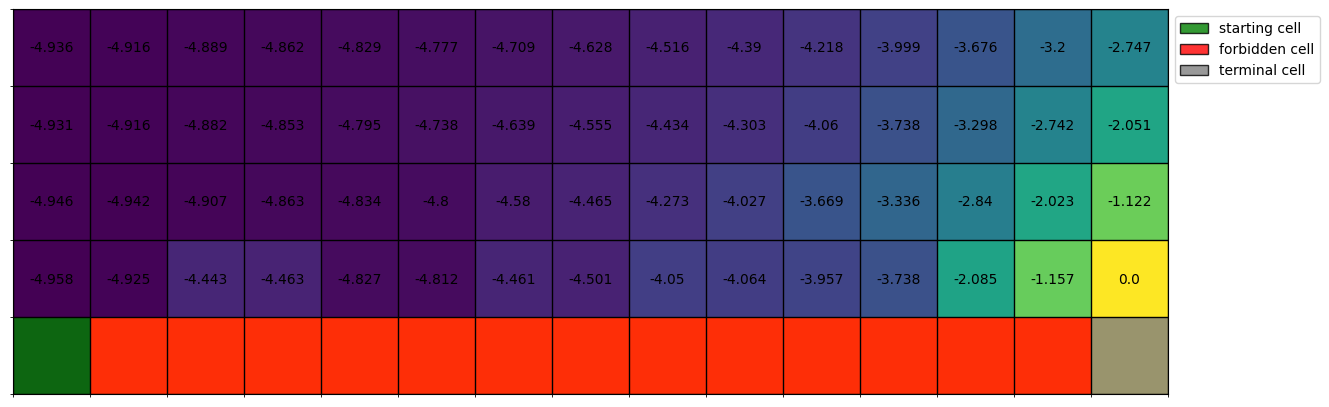

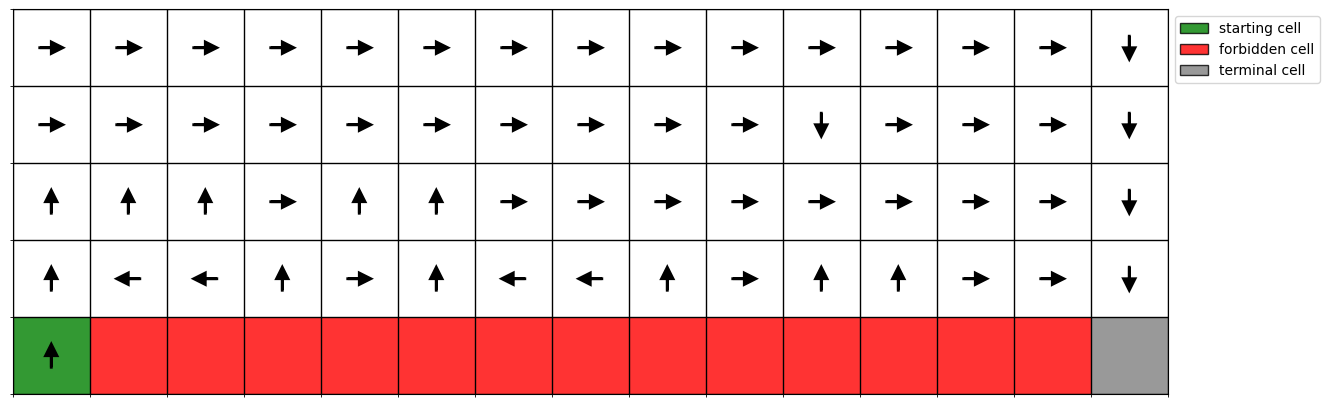

In [16]:
Qstar = np.round(np.max(Q,axis = 2),3)

savepath = folder_name + '/4_SARSA_value.png'
plot_grid_value(Qstar,color_gradient,start_cells,forbidden_cells,terminal_cells,savepath)

savepath = folder_name + '/4_SARSA_actions.png'
plot_grid_actions(np.argmax(Q,axis = 2),start_cells,forbidden_cells,terminal_cells,savepath)
    

In [17]:
policy = np.argmax(Q,axis = 2)
eval_episodes = 100
eval_mean_r,eval_std_r,eval_mean_s,eval_std_s = policy_evaluator(policy,gridworld,start_cells,terminal_cells,forbidden_cells,max_steps,eval_episodes,slip)


avg_rewards = []
for i in range(1,len(rewards)):
    avg_rewards.append(np.sum(rewards[:i])/i)

avg_path = []
for i in range(1,len(path_lengths)):
    avg_path.append(np.sum(path_lengths[:i])/i)


SARSA_dict = {
    'episodes':n_episodes,
    'avg_rewards':avg_rewards,
    'rewards':rewards,
    'epsilon':epsilon,
    'gamma':gamma,
    'avg_path_length':avg_path,
    'EVAL_episodes':eval_episodes,
    'EVAL_mean_reward':eval_mean_r,
    'EVAL_std_reward':eval_std_r,
    'EVAL_mean_steps':eval_mean_s,
    'EVAL_std_steps':eval_std_s
}

In [18]:
print(f'EVAL Reward mean: {eval_mean_r} +- {eval_std_r}')
print(f'EVAL Steps mean: {eval_mean_s} +- {eval_std_s}')


EVAL Reward mean: -23.03 +- 2.295452025201137
EVAL Steps mean: 23.03 +- 2.295452025201137


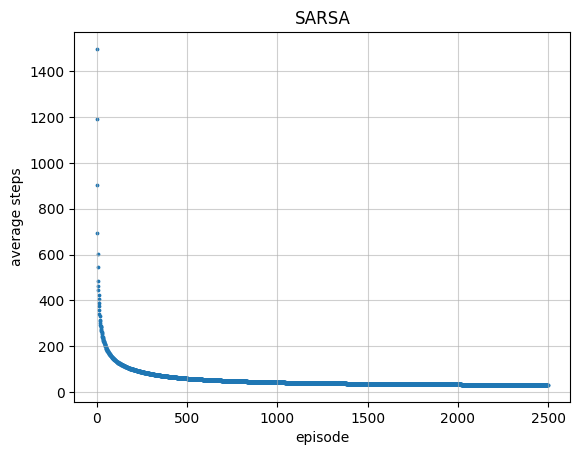

In [19]:
plt.scatter(np.arange(0,len(avg_path),1),avg_path,s =3)
plt.xlabel('episode')
plt.ylabel('average steps')
plt.grid(alpha = 0.6)
plt.title('SARSA')

savepath = folder_name + '/4_SARSA_steps.png'
plt.savefig(savepath)
plt.show()

### Comparison plot

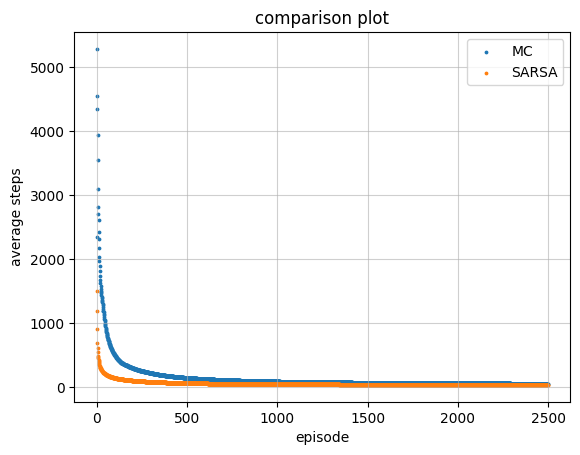

In [20]:
plt.scatter(np.arange(0,len(MC_dict['avg_path_length']),1),MC_dict['avg_path_length'],s =3,label = 'MC')
plt.scatter(np.arange(0,len(SARSA_dict['avg_path_length']),1),SARSA_dict['avg_path_length'],s =3,label = 'SARSA')
plt.xlabel('episode')
plt.ylabel('average steps')
plt.legend()
plt.grid(alpha = 0.6)
#plt.ylim(-2,15)
plt.title('comparison plot')

plt.show()

We indeed observe that SARSA outperforms MC, even though MC has found an optimal strategy pretty quickly. Though, this is luck-based, and is not guaranteed that MC finds the exit in a low number of episodes (we had runs in which MC did not find the exit, having an average steps constant as the number of max steps)

# Bayesian Inference solution
The Bayesian Inference solution is Posterior Sampling here too, since the problem has multiple states and actions. The algorithm is the following:

1) Initialize $P(\cdot|s,a)\sim Dir(\alpha_{s,a})$ as Dirichlet distributed
2) Sample the MDP from $P$
3) Compute optimal value function $V(s)$ and optimal state-action value function $Q(s,a)$ from the obtained sample of $P$
4) Determine the greedy policy $\pi(s) = argmax_aQ(s,a)$ for all states
5) Update the posterior for any visited tuple $(s,a,s')$: $\alpha_{s,a}(s')\gets \alpha_{s,a}(s')+1$
6) Repeat from 2. with the updated distribution

Posterior Sampling is expected to still outperform SARSA and MC, but only slightly. The nature of the problem does not penalize much traditional RL algorithms as the chain problem did, hence we expect to see a small but relevant improvement, mostly in early episodes.

In [27]:
n_outcomes = 5
n_actions = 4
start_row, start_col = start_cells[0]

# Dirichlet posterior (s, a, 5 outcomes)
alpha = np.ones((h, b, n_actions, n_outcomes))
# possible next states
next_states = np.zeros((h, b, n_actions, n_outcomes, 2), dtype=int)

for s_row in range(h):
    for s_col in range(b):
        for a in range(n_actions):

            intended = np.array([s_row, s_col]) + ACTION_DELTAS[a]
            if not (0 <= intended[0] < h and 0 <= intended[1] < b):
                intended = np.array([s_row, s_col])

            slip_state = np.array([s_row, s_col]) + ACTION_DELTAS[1]
            if not (0 <= slip_state[0] < h and 0 <= slip_state[1] < b):
                slip_state = np.array([s_row, s_col])

            candidates = [
                tuple(intended),               # intended
                tuple(slip_state),             # slip
                (s_row, s_col),                # stay
                (start_row, start_col),        # reset
                (s_row, s_col)                 # placeholder
            ]

            for k in range(n_outcomes):
                next_states[s_row, s_col, a, k] = candidates[k]


def value_iteration_sparse(P_sample, gamma):
    Q = np.zeros((h, b, n_actions))

    for _ in range(100):
        Q_new = np.zeros_like(Q)

        for s_row in range(h):
            for s_col in range(b):

                if (s_row, s_col) in terminal_cells:
                    continue

                for a in range(n_actions):

                    val = 0
                    for k in range(n_outcomes):
                        prob = P_sample[s_row, s_col, a, k]   
                        s2_row, s2_col = next_states[s_row, s_col, a, k]

                        if (s2_row, s2_col) in forbidden_cells:
                            r = -100
                            s2_row, s2_col = start_row, start_col
                        else:
                            r = -1

                        val += prob * (r + gamma * np.max(Q[s2_row, s2_col]))

                    Q_new[s_row, s_col, a] = val

        if np.max(np.abs(Q - Q_new)) < 1e-6:
            break

        Q = Q_new

    return Q

################
# episode loop #
################

for episode in range(n_episodes):
    print('training episode',episode)
    # 1) sample sparse transition model
    P_sample = np.zeros((h, b, n_actions, n_outcomes))

    for s_row in range(h):
        for s_col in range(b):
            for a in range(n_actions):

                if (s_row, s_col) in terminal_cells:
                    P_sample[s_row, s_col, a] = np.array([1,0,0,0,0])
                else:
                    P_sample[s_row, s_col, a] = \
                        np.random.dirichlet(alpha[s_row, s_col, a])

    # 2) optimal value function to determine policy with value iteration
    Q = value_iteration_sparse(P_sample, gamma)
    policy = np.argmax(Q, axis=2)

    # 3) run real episode with determined policy
    state = np.array(start_cells[0])
    step_counter = 0

    while step_counter < max_steps and tuple(state) not in terminal_cells:

        action = policy[state[0], state[1]]

        if np.random.rand() < slip:
            action = 1

        new_state = state + ACTION_DELTAS[action]

        if not (0 <= new_state[0] < h and 0 <= new_state[1] < b):
            new_state = state

        if tuple(new_state) in forbidden_cells:
            r = -100
            new_state = np.array(start_cells[0])
        else:
            r = -1

        # 4) update posterior
        for k in range(n_outcomes):
            if tuple(next_states[state[0], state[1], action, k]) == tuple(new_state):
                alpha[state[0], state[1], action, k] += 1
                break

        state = new_state
        step_counter += 1

training episode 0
training episode 1
training episode 2
training episode 3
training episode 4
training episode 5
training episode 6
training episode 7
training episode 8
training episode 9
training episode 10
training episode 11
training episode 12
training episode 13
training episode 14
training episode 15
training episode 16
training episode 17
training episode 18
training episode 19
training episode 20
training episode 21
training episode 22
training episode 23
training episode 24
training episode 25
training episode 26
training episode 27
training episode 28
training episode 29
training episode 30
training episode 31
training episode 32
training episode 33
training episode 34
training episode 35
training episode 36
training episode 37
training episode 38
training episode 39
training episode 40
training episode 41
training episode 42
training episode 43
training episode 44
training episode 45
training episode 46
training episode 47
training episode 48
training episode 49
training e

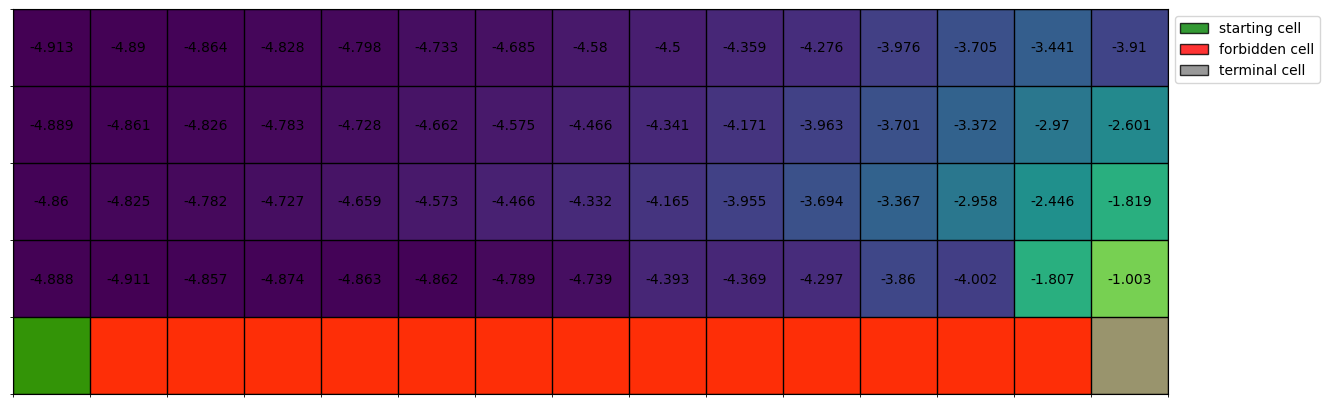

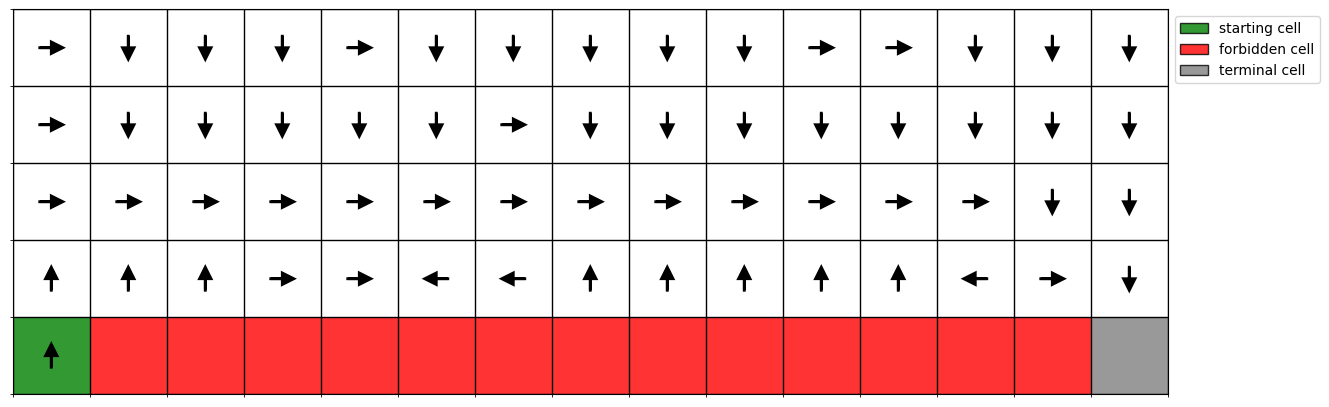

In [28]:
Qstar = np.round(np.max(Q,axis = 2),3)
Qstar[-1,:] = np.zeros(len(Qstar[-1,:]))

savepath = folder_name + '/6_BayesianInference_value.png'
plot_grid_value(Qstar,color_gradient,start_cells,forbidden_cells,terminal_cells,savepath)

savepath = folder_name + '/6_BayesianInference_actions.png'
plot_grid_actions(np.argmax(Q,axis = 2),start_cells,forbidden_cells,terminal_cells,savepath)
    

In [29]:
policy = np.argmax(Q,axis = 2)
eval_episodes = 100
eval_mean_r,eval_std_r,eval_mean_s,eval_std_s = policy_evaluator(policy,gridworld,start_cells,terminal_cells,forbidden_cells,max_steps,eval_episodes,slip)


avg_rewards = []
for i in range(1,len(rewards)):
    avg_rewards.append(np.sum(rewards[:i])/i)

avg_path = []
for i in range(1,len(path_lengths)):
    avg_path.append(np.sum(path_lengths[:i])/i)


Bayesian_dict = {
    'episodes':n_episodes,
     #'avg_rewards':avg_rewards,
     #'rewards':rewards,
    'epsilon':epsilon,
    'gamma':gamma,
    'avg_path_length':avg_path,
    'EVAL_episodes':eval_episodes,
    'EVAL_mean_reward':eval_mean_r,
    'EVAL_std_reward':eval_std_r,
    'EVAL_mean_steps':eval_mean_s,
    'EVAL_std_steps':eval_std_s
}

In [30]:
print(eval_mean_s,eval_std_s)

21.53 2.9238844026397492


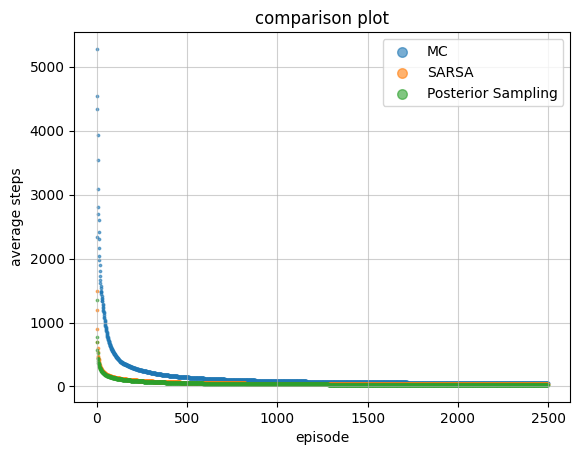

In [31]:
plt.scatter(np.arange(0,len(MC_dict['avg_path_length']),1),MC_dict['avg_path_length'],s =3,label = 'MC',alpha = 0.6)
plt.scatter(np.arange(0,len(SARSA_dict['avg_path_length']),1),SARSA_dict['avg_path_length'],s =3,label = 'SARSA',alpha = 0.6)
#plt.scatter(np.arange(0,len(Qlearning_dict['avg_path_length']),1),Qlearning_dict['avg_path_length'],s =3,label = 'Q-Learning',alpha = 0.6)
plt.scatter(np.arange(0,len(Bayesian_dict['avg_path_length']),1),Bayesian_dict['avg_path_length'],s =3,label = 'Posterior Sampling',alpha = 0.6)
plt.xlabel('episode')
plt.ylabel('average steps')
plt.legend(markerscale = 4)
plt.grid(alpha = 0.6)
#plt.ylim(-2,15)
plt.title('comparison plot')

savepath = folder_name + '/7_all_steps.png'
plt.savefig(savepath)
plt.show()

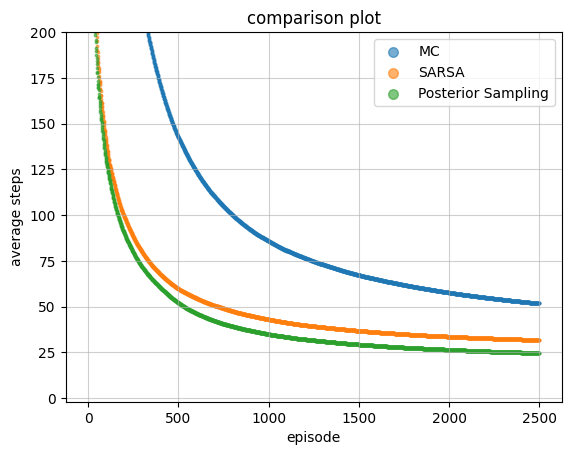

In [32]:
plt.scatter(np.arange(0,len(MC_dict['avg_path_length']),1),MC_dict['avg_path_length'],s =3,label = 'MC',alpha = 0.6)
plt.scatter(np.arange(0,len(SARSA_dict['avg_path_length']),1),SARSA_dict['avg_path_length'],s =3,label = 'SARSA',alpha = 0.6)
#plt.scatter(np.arange(0,len(Qlearning_dict['avg_path_length']),1),Qlearning_dict['avg_path_length'],s =3,label = 'Q-Learning',alpha = 0.6)
plt.scatter(np.arange(0,len(Bayesian_dict['avg_path_length']),1),Bayesian_dict['avg_path_length'],s =3,label = 'Posterior Sampling',alpha = 0.6)
plt.xlabel('episode')
plt.ylabel('average steps')
plt.legend(markerscale = 4)
plt.grid(alpha = 0.6)
plt.ylim(-2,200)
plt.title('comparison plot')

savepath = folder_name + '/7_all_steps_zoom_y.png'
plt.savefig(savepath)
plt.show()

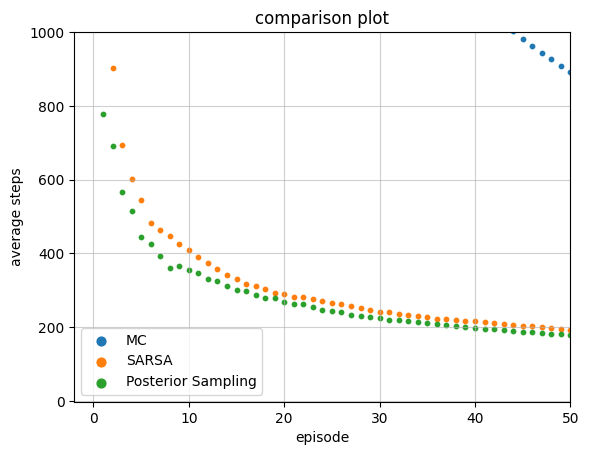

In [33]:
plt.scatter(np.arange(0,len(MC_dict['avg_path_length']),1),MC_dict['avg_path_length'],s =10,label = 'MC',alpha = 1)
plt.scatter(np.arange(0,len(SARSA_dict['avg_path_length']),1),SARSA_dict['avg_path_length'],s =10,label = 'SARSA',alpha = 1)
#plt.scatter(np.arange(0,len(Qlearning_dict['avg_path_length']),1),Qlearning_dict['avg_path_length'],s =10,label = 'Q-Learning',alpha = 0.6)
plt.scatter(np.arange(0,len(Bayesian_dict['avg_path_length']),1),Bayesian_dict['avg_path_length'],s =10,label = 'Posterior Sampling',alpha = 1)
plt.xlabel('episode')
plt.ylabel('average steps')
plt.legend(markerscale = 2)
plt.grid(alpha = 0.6)
plt.xlim(-2,50)
plt.ylim(-2,1000)
plt.title('comparison plot')

savepath = folder_name + '/7_all_steps_zoom_x.png'
plt.savefig(savepath)
plt.show()

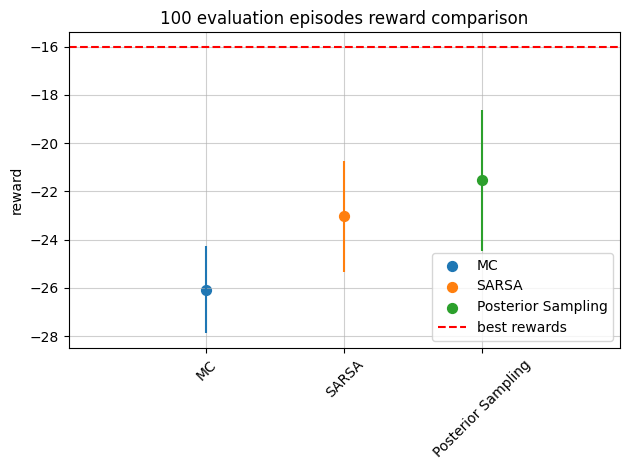

In [34]:
dotsize = 50
plt.scatter(0,MC_dict['EVAL_mean_reward'],label = 'MC',s=dotsize)
plt.scatter(1,SARSA_dict['EVAL_mean_reward'],label = 'SARSA',s=dotsize)
#plt.scatter(2,Qlearning_dict['EVAL_mean_reward'],label = 'Q-learning',s=dotsize)
plt.scatter(2,Bayesian_dict['EVAL_mean_reward'],label = 'Posterior Sampling',s=dotsize)

plt.hlines(-b-1,-1,3,label = 'best rewards', color = 'red',ls = '--')

plt.errorbar(0,MC_dict['EVAL_mean_reward'],yerr=MC_dict['EVAL_std_reward'])
plt.errorbar(1,SARSA_dict['EVAL_mean_reward'],yerr=SARSA_dict['EVAL_std_reward'])
#plt.errorbar(2,Qlearning_dict['EVAL_mean_reward'],yerr=Qlearning_dict['EVAL_std_reward'],label = 'Q-learning')
plt.errorbar(2,Bayesian_dict['EVAL_mean_reward'],yerr=Bayesian_dict['EVAL_std_reward'])
plt.title(f'{MC_dict['EVAL_episodes']} evaluation episodes reward comparison')
plt.ylabel('reward')
plt.xticks(np.arange(0,3,1),labels = ['MC','SARSA','Posterior Sampling'],rotation = 45.)
plt.xlim(-1,3)
plt.legend( loc = 'lower right')
plt.grid(alpha = 0.6)
savepath = folder_name + '/7_EVAL_comparison_reward.png'
#plt.yscale('log')
plt.tight_layout()
plt.savefig(savepath)
plt.show()

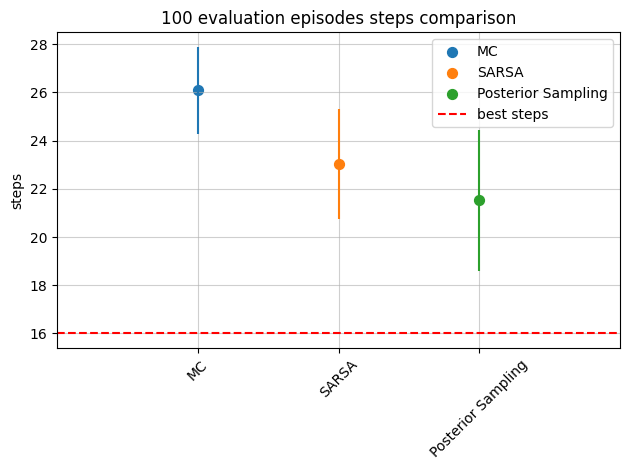

In [35]:
dotsize = 50
plt.scatter(0,MC_dict['EVAL_mean_steps'],label = 'MC',s=dotsize)
plt.scatter(1,SARSA_dict['EVAL_mean_steps'],label = 'SARSA',s=dotsize)
#plt.scatter(2,Qlearning_dict['EVAL_mean_steps'],label = 'Q-learning',s=dotsize)
plt.scatter(2,Bayesian_dict['EVAL_mean_steps'],label = 'Posterior Sampling',s=dotsize)

plt.hlines(b+1,-1,3,label = 'best steps', color = 'red',ls = '--')

plt.errorbar(0,MC_dict['EVAL_mean_steps'],yerr=MC_dict['EVAL_std_steps'])
plt.errorbar(1,SARSA_dict['EVAL_mean_steps'],yerr=SARSA_dict['EVAL_std_steps'])
#plt.errorbar(2,Qlearning_dict['EVAL_mean_steps'],yerr=Qlearning_dict['EVAL_std_steps'],label = 'Q-learning')
plt.errorbar(2,Bayesian_dict['EVAL_mean_steps'],yerr=Bayesian_dict['EVAL_std_steps'])
plt.title(f'{MC_dict['EVAL_episodes']} evaluation episodes steps comparison')
plt.ylabel('steps')
plt.xticks(np.arange(0,3,1),labels = ['MC','SARSA','Posterior Sampling'],rotation = 45.)
plt.legend()
plt.grid(alpha = 0.6)
plt.xlim(-1,3)

plt.tight_layout()
savepath = folder_name + '/7_EVAL_comparison_steps.png'
plt.savefig(savepath)
plt.show()

### backup of dictionaries

In [36]:
log_path = folder_name + '/MC_log.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(MC_dict.keys(),MC_dict.values()):
        print(f"{key}: {value}",file = text_file)

log_path = folder_name + '/SARSA_log.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(SARSA_dict.keys(),SARSA_dict.values()):
        print(f"{key}: {value}",file = text_file)

log_path = folder_name + '/Qlearning_log.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(Qlearning_dict.keys(),Qlearning_dict.values()):
        print(f"{key}: {value}",file = text_file)

log_path = folder_name + '/BayesianInference_log.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(Bayesian_dict.keys(),Bayesian_dict.values()):
        print(f"{key}: {value}",file = text_file)

In [37]:
SARSA_dict = {
    'episodes':n_episodes,
    'avg_rewards':avg_rewards,
    'rewards':rewards,
    'epsilon':epsilon,
    'gamma':gamma,
    'avg_path_length':avg_path,
    'EVAL_episodes':eval_episodes,
    'EVAL_mean_reward':eval_mean_r,
    'EVAL_std_reward':eval_std_r,
    'EVAL_mean_steps':eval_mean_s,
    'EVAL_std_steps':eval_std_s
}

In [38]:
print(MC_dict['EVAL_mean_steps'],MC_dict['EVAL_std_steps'])

26.09 1.8060730882220686


In [39]:
print(SARSA_dict['EVAL_mean_steps'],SARSA_dict['EVAL_std_steps'])

21.53 2.9238844026397492


In [40]:
print(Bayesian_dict['EVAL_mean_steps'],Bayesian_dict['EVAL_std_steps'])

21.53 2.9238844026397492
